In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = '/content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1'
HOSP_PATH   = f'{BASE_PATH}/hosp'
ICU_PATH    = f'{BASE_PATH}/icu'
OUTPUT_PATH = f'{BASE_PATH}/fl_clients'

os.makedirs(OUTPUT_PATH, exist_ok=True)
print("Setup done ✓")

Mounted at /content/drive
Setup done ✓


In [2]:
print("Loading core tables...")

admissions = pd.read_csv(f'{HOSP_PATH}/admissions.csv.gz',
                         compression='gzip',
                         usecols=['subject_id','hadm_id',
                                  'hospital_expire_flag',
                                  'insurance','race',
                                  'admittime','dischtime',
                                  'admission_type'])

patients = pd.read_csv(f'{HOSP_PATH}/patients.csv.gz',
                       compression='gzip',
                       usecols=['subject_id','anchor_age','gender'])

icustays = pd.read_csv(f'{ICU_PATH}/icustays.csv.gz',
                       compression='gzip',
                       usecols=['subject_id','hadm_id','stay_id',
                                'first_careunit','last_careunit','los'])

# Merge into master
df = icustays.merge(admissions, on=['subject_id','hadm_id'])
df = df.merge(patients, on='subject_id')
df['mortality'] = df['hospital_expire_flag'].astype(int)

# Encode demographics
df['gender_enc']         = (df['gender'] == 'M').astype(int)
df['insurance_enc']      = df['insurance'].astype('category').cat.codes
df['race_enc']           = df['race'].astype('category').cat.codes
df['admission_type_enc'] = df['admission_type'].astype('category').cat.codes

print(f"Master shape     : {df.shape}")
print(f"Mortality rate   : {df['mortality'].mean()*100:.1f}%")
print(f"\nCare units:\n{df['first_careunit'].value_counts()}")

Loading core tables...
Master shape     : (94458, 19)
Mortality rate   : 12.0%

Care units:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Medicine/Cardiology Intermediate                        1
Med/Surg               

In [3]:
LAB_ITEMIDS = {
    50809: 'glucose_bg',    50811: 'hemoglobin_bg', 50813: 'lactate',
    50820: 'pH',            50861: 'ALT',            50862: 'albumin',
    50878: 'AST',           50882: 'bicarbonate',    50885: 'bilirubin_total',
    50893: 'calcium',       50902: 'chloride',       50912: 'creatinine',
    50931: 'glucose',       50960: 'magnesium',      50971: 'potassium',
    50983: 'sodium',        51003: 'troponin_T',     51006: 'BUN',
    51221: 'hematocrit',    51222: 'hemoglobin',     51237: 'INR',
    51265: 'platelet',      51275: 'PTT',            51301: 'WBC',
}

valid_hadm_ids = set(df['hadm_id'].unique())
stats = defaultdict(lambda: [0.0, 0.0, np.inf, -np.inf, 0, 0, 0])

print("Streaming labevents (~10-12 min)...")
i = 0
for chunk in pd.read_csv(
        f'{HOSP_PATH}/labevents.csv-003.gz',
        compression='gzip',
        chunksize=200_000,
        usecols=['hadm_id','itemid','valuenum','flag','priority']):

    chunk = chunk[
        chunk['itemid'].isin(LAB_ITEMIDS.keys()) &
        chunk['hadm_id'].isin(valid_hadm_ids) &
        chunk['valuenum'].notna()
    ].copy()

    if len(chunk) == 0:
        i += 1
        continue

    chunk['lab_name']    = chunk['itemid'].map(LAB_ITEMIDS)
    chunk['is_abnormal'] = chunk['flag'].notna().astype(int)
    chunk['is_stat']     = (chunk['priority'] == 'STAT').astype(int)

    for (hadm_id, lab_name), grp in chunk.groupby(['hadm_id','lab_name']):
        key  = (hadm_id, lab_name)
        vals = grp['valuenum'].values
        stats[key][0] += vals.sum()
        stats[key][1] += (vals ** 2).sum()
        stats[key][2]  = min(stats[key][2], vals.min())
        stats[key][3]  = max(stats[key][3], vals.max())
        stats[key][4] += len(vals)
        stats[key][5] += int(grp['is_abnormal'].sum())
        stats[key][6] += int(grp['is_stat'].sum())

    i += 1
    if i % 10 == 0:
        print(f"  Chunk {i} done...", end='\r')

print(f"\nDone. Pairs: {len(stats):,}")

rows = []
for (hadm_id, lab_name), s in stats.items():
    n        = s[4]
    mean_val = s[0] / n
    std_val  = np.sqrt(max(s[1]/n - mean_val**2, 0))
    rows.append({
        'hadm_id'   : hadm_id,
        'lab_name'  : lab_name,
        'mean_val'  : mean_val,
        'min_val'   : s[2],
        'max_val'   : s[3],
        'std_val'   : std_val,
        'n_measured': n,
        'n_abnormal': s[5],
        'n_stat'    : s[6],
    })

agg = pd.DataFrame(rows)
lab_pivot = agg.pivot_table(
    index   = 'hadm_id',
    columns = 'lab_name',
    values  = ['mean_val','min_val','max_val','std_val',
               'n_measured','n_abnormal','n_stat']
)
lab_pivot.columns  = [f'lab_{v}_{c}' for v, c in lab_pivot.columns]
lab_pivot          = lab_pivot.reset_index()

df = df.merge(lab_pivot, on='hadm_id', how='left')
print(f"Master shape after labs: {df.shape}")
print(f"Lab columns: {len([c for c in df.columns if c.startswith('lab_')])}")

Streaming labevents (~10-12 min)...

Done. Pairs: 1,659,587
Master shape after labs: (94458, 187)
Lab columns: 168


In [4]:
# 14 core ICU vitals — clinically meaningful for mortality
VITAL_ITEMIDS = {
    220045: 'heart_rate',
    220179: 'sbp',              # systolic BP non-invasive
    220180: 'dbp',              # diastolic BP non-invasive
    220052: 'sbp_invasive',     # arterial line systolic
    220050: 'dbp_invasive',     # arterial line diastolic
    220181: 'map',              # mean arterial pressure
    220210: 'resp_rate',
    220277: 'spo2',
    223762: 'temp_celsius',
    220739: 'gcs_eye',
    223900: 'gcs_verbal',
    223901: 'gcs_motor',
    223835: 'fio2',             # fraction of inspired O2
    224700: 'peep',             # ventilator pressure
}

valid_stay_ids = set(df['stay_id'].unique())
vstats = defaultdict(lambda: [0.0, 0.0, np.inf, -np.inf, 0, 0])

print("Streaming chartevents (~15-18 min)...")
i = 0
for chunk in pd.read_csv(
        f'{ICU_PATH}/chartevents.csv-002.gz',
        compression='gzip',
        chunksize=200_000,
        usecols=['stay_id','itemid','valuenum','warning']):

    chunk = chunk[
        chunk['itemid'].isin(VITAL_ITEMIDS.keys()) &
        chunk['stay_id'].isin(valid_stay_ids) &
        chunk['valuenum'].notna()
    ].copy()

    if len(chunk) == 0:
        i += 1
        continue

    chunk['vital_name'] = chunk['itemid'].map(VITAL_ITEMIDS)
    chunk['is_warning'] = chunk['warning'].fillna(0).astype(int)

    for (stay_id, vital_name), grp in chunk.groupby(['stay_id','vital_name']):
        key  = (stay_id, vital_name)
        vals = grp['valuenum'].values
        vstats[key][0] += vals.sum()
        vstats[key][1] += (vals ** 2).sum()
        vstats[key][2]  = min(vstats[key][2], vals.min())
        vstats[key][3]  = max(vstats[key][3], vals.max())
        vstats[key][4] += len(vals)
        vstats[key][5] += int(grp['is_warning'].sum())

    i += 1
    if i % 20 == 0:
        print(f"  Chunk {i} done...", end='\r')

print(f"\nDone. Pairs: {len(vstats):,}")

vrows = []
for (stay_id, vital_name), s in vstats.items():
    n        = s[4]
    mean_val = s[0] / n
    std_val  = np.sqrt(max(s[1]/n - mean_val**2, 0))
    vrows.append({
        'stay_id'   : stay_id,
        'vital_name': vital_name,
        'mean_val'  : mean_val,
        'min_val'   : s[2],
        'max_val'   : s[3],
        'std_val'   : std_val,
        'n_measured': n,
        'n_warning' : s[5],
    })

vagg = pd.DataFrame(vrows)
vitals_pivot = vagg.pivot_table(
    index   = 'stay_id',
    columns = 'vital_name',
    values  = ['mean_val','min_val','max_val','std_val',
               'n_measured','n_warning']
)
vitals_pivot.columns = [f'vital_{v}_{c}' for v, c in vitals_pivot.columns]
vitals_pivot         = vitals_pivot.reset_index()

df = df.merge(vitals_pivot, on='stay_id', how='left')
print(f"Master shape after vitals: {df.shape}")
print(f"Vital columns: {len([c for c in df.columns if c.startswith('vital_')])}")

Streaming chartevents (~15-18 min)...

Done. Pairs: 1,003,610
Master shape after vitals: (94458, 271)
Vital columns: 84


In [5]:
print("Loading outputevents...")

URINE_ITEMIDS = [226559,226560,226561,226584,226563,
                 226564,226565,226567,226557,226558]

outputevents = pd.read_csv(f'{ICU_PATH}/outputevents.csv.gz',
                            compression='gzip',
                            usecols=['stay_id','itemid','value'])

urine = outputevents[outputevents['itemid'].isin(URINE_ITEMIDS)]
urine_agg = urine.groupby('stay_id')['value'].agg(
    urine_total = 'sum',
    urine_mean  = 'mean',
    urine_count = 'count',
).reset_index()

df = df.merge(urine_agg, on='stay_id', how='left')
df['urine_total'] = df['urine_total'].fillna(0)
df['urine_mean']  = df['urine_mean'].fillna(0)
df['urine_count'] = df['urine_count'].fillna(0)

print(f"Master shape after urine: {df.shape}")

Loading outputevents...
Master shape after urine: (94458, 274)


In [6]:
print("Loading inputevents (vasopressors)...")

# Key vasopressor itemids in MIMIC-IV
VASOPRESSOR_ITEMIDS = {
    221906: 'norepinephrine',
    221289: 'epinephrine',
    222315: 'vasopressin',
    221749: 'phenylephrine',
    221662: 'dopamine',
}

inputevents = pd.read_csv(f'{ICU_PATH}/inputevents.csv.gz',
                           compression='gzip',
                           usecols=['stay_id','itemid','amount'])

vasopressors = inputevents[inputevents['itemid'].isin(VASOPRESSOR_ITEMIDS.keys())].copy()
vasopressors['vaso_name'] = vasopressors['itemid'].map(VASOPRESSOR_ITEMIDS)

# Binary flag per patient — did they receive this vasopressor?
vaso_pivot = vasopressors.groupby(['stay_id','vaso_name'])['amount'].sum().unstack(fill_value=0)
vaso_pivot.columns = [f'vaso_{c}' for c in vaso_pivot.columns]

# Convert to binary (1 = received, 0 = not)
for col in vaso_pivot.columns:
    vaso_pivot[col] = (vaso_pivot[col] > 0).astype(int)

vaso_pivot = vaso_pivot.reset_index()

df = df.merge(vaso_pivot, on='stay_id', how='left')
# Fill missing with 0 (patient never received that vasopressor)
for col in [c for c in df.columns if c.startswith('vaso_')]:
    df[col] = df[col].fillna(0).astype(int)

print(f"Master shape after vasopressors: {df.shape}")
print(f"Vasopressor columns: {[c for c in df.columns if c.startswith('vaso_')]}")

Loading inputevents (vasopressors)...
Master shape after vasopressors: (94458, 279)
Vasopressor columns: ['vaso_dopamine', 'vaso_epinephrine', 'vaso_norepinephrine', 'vaso_phenylephrine', 'vaso_vasopressin']


In [7]:
client_map = {
    'Medical Intensive Care Unit (MICU)'               : 0,
    'Medical/Surgical Intensive Care Unit (MICU/SICU)' : 0,
    'Surgical Intensive Care Unit (SICU)'              : 1,
    'Trauma SICU (TSICU)'                              : 1,
    'Coronary Care Unit (CCU)'                         : 2,
    'Cardiac Vascular Intensive Care Unit (CVICU)'     : 2,
    'Neuro Intermediate'                               : 2,
    'Neuro Stepdown'                                   : 2,
}

df['client_id'] = df['first_careunit'].map(client_map)

unmapped = df[df['client_id'].isna()]['first_careunit'].unique()
if len(unmapped):
    print(f"⚠️  Unmapped units (will be dropped): {unmapped}")

df          = df.dropna(subset=['client_id'])
df['client_id'] = df['client_id'].astype(int)

client0 = df[df['client_id'] == 0].reset_index(drop=True)
client1 = df[df['client_id'] == 1].reset_index(drop=True)
client2 = df[df['client_id'] == 2].reset_index(drop=True)
clients = [client0, client1, client2]

print(f"Client 0 (Medical)  : {len(client0):,} stays")
print(f"Client 1 (Surgical) : {len(client1):,} stays")
print(f"Client 2 (Cardiac)  : {len(client2):,} stays")

⚠️  Unmapped units (will be dropped): ['Neuro Surgical Intensive Care Unit (Neuro SICU)'
 'Surgery/Vascular/Intermediate' 'Intensive Care Unit (ICU)' 'PACU'
 'Medicine' 'Surgery/Trauma' 'Medicine/Cardiology Intermediate' 'Med/Surg'
 'Neurology']
Client 0 (Medical)  : 36,152 stays
Client 1 (Surgical) : 23,483 stays
Client 2 (Cardiac)  : 32,743 stays



Client                    Size  Mortality%   Avg Age   Avg LOS    Vaso%
----------------------------------------------------------------------
Client 0 (Medical)      36,152       16.1%      61.8      3.47    25.3%
Client 1 (Surgical)     23,483       11.5%      61.2      3.79    23.2%
Client 2 (Cardiac)      32,743        6.9%      65.7      3.58    36.0%


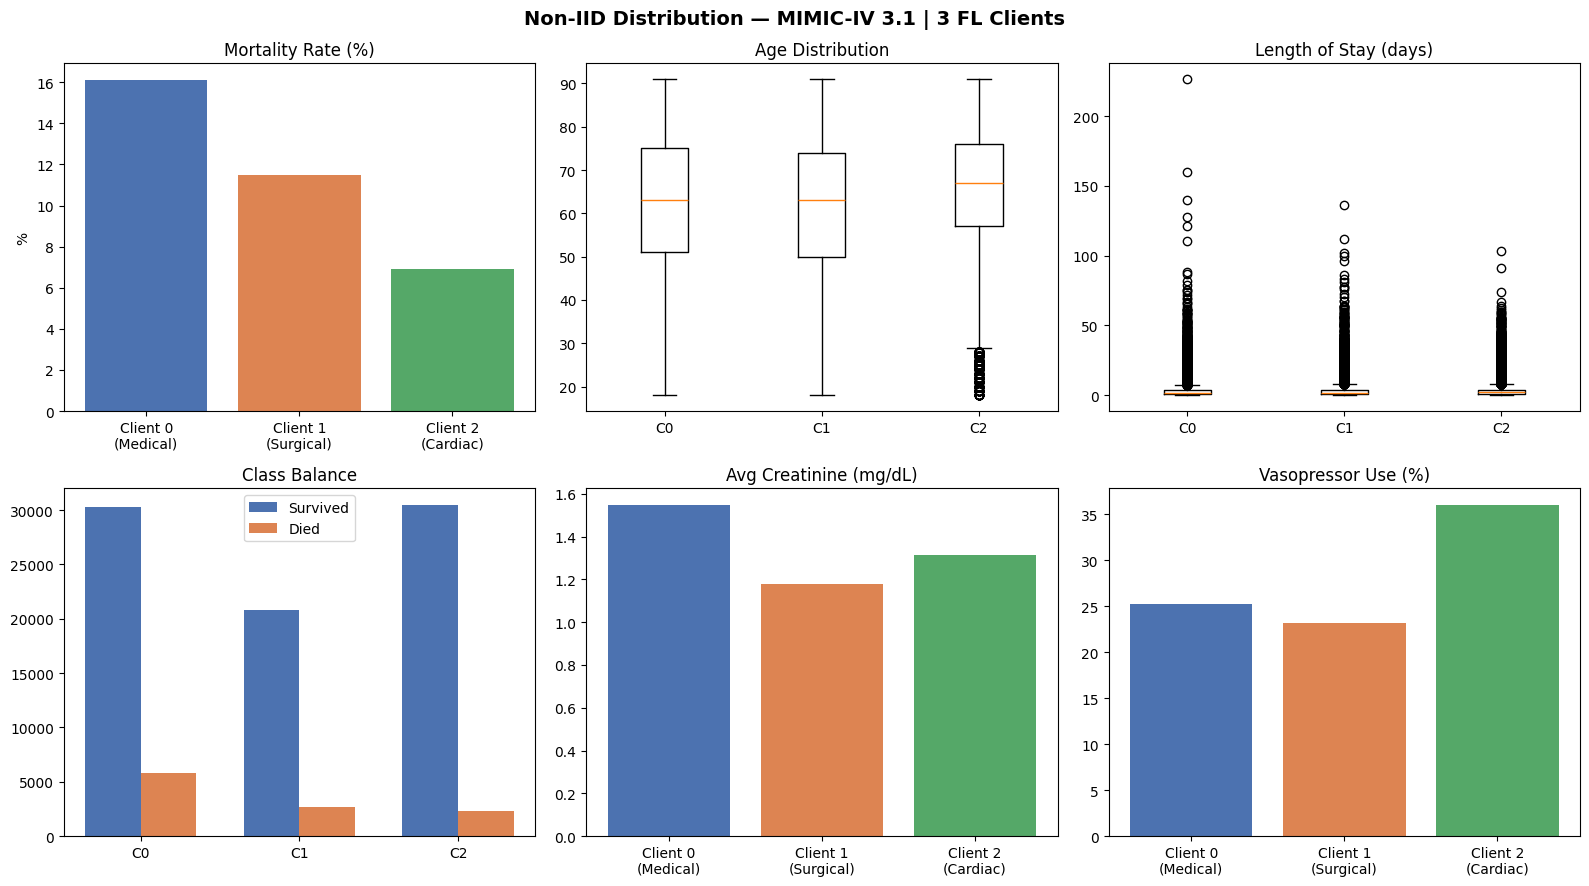

Plot saved ✓


In [8]:
names  = ['Client 0\n(Medical)', 'Client 1\n(Surgical)', 'Client 2\n(Cardiac)']
colors = ['#4C72B0','#DD8452','#55A868']

print(f"\n{'Client':<22} {'Size':>7} {'Mortality%':>11} {'Avg Age':>9} "
      f"{'Avg LOS':>9} {'Vaso%':>8}")
print("-" * 70)
for name, c in zip(names, clients):
    vaso_cols = [col for col in c.columns if col.startswith('vaso_')]
    vaso_any  = (c[vaso_cols].sum(axis=1) > 0).mean() * 100 if vaso_cols else 0
    print(f"{name.replace(chr(10),' '):<22} {len(c):>7,} "
          f"{c['mortality'].mean()*100:>10.1f}% "
          f"{c['anchor_age'].mean():>9.1f} "
          f"{c['los'].mean():>9.2f} "
          f"{vaso_any:>7.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Non-IID Distribution — MIMIC-IV 3.1 | 3 FL Clients',
             fontsize=14, fontweight='bold')

# Mortality rate
axes[0,0].bar(names, [c['mortality'].mean()*100 for c in clients], color=colors)
axes[0,0].set_title('Mortality Rate (%)')
axes[0,0].set_ylabel('%')

# Age
axes[0,1].boxplot([c['anchor_age'].dropna().values for c in clients],
                   labels=['C0','C1','C2'])
axes[0,1].set_title('Age Distribution')

# LOS
axes[0,2].boxplot([c['los'].dropna().values for c in clients],
                   labels=['C0','C1','C2'])
axes[0,2].set_title('Length of Stay (days)')

# Class balance
x, w = np.arange(3), 0.35
axes[1,0].bar(x-w/2, [c[c['mortality']==0].shape[0] for c in clients],
               w, label='Survived', color='#4C72B0')
axes[1,0].bar(x+w/2, [c[c['mortality']==1].shape[0] for c in clients],
               w, label='Died',     color='#DD8452')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['C0','C1','C2'])
axes[1,0].set_title('Class Balance')
axes[1,0].legend()

# Creatinine
if 'lab_mean_val_creatinine' in df.columns:
    axes[1,1].bar(names,
                  [c['lab_mean_val_creatinine'].mean() for c in clients],
                  color=colors)
    axes[1,1].set_title('Avg Creatinine (mg/dL)')

# Vasopressor usage
vaso_cols = [col for col in df.columns if col.startswith('vaso_')]
if vaso_cols:
    vaso_rates = [(c[vaso_cols].sum(axis=1) > 0).mean()*100 for c in clients]
    axes[1,2].bar(names, vaso_rates, color=colors)
    axes[1,2].set_title('Vasopressor Use (%)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/noniid_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

In [9]:
# Columns to EXCLUDE from features (IDs, labels, raw strings)
EXCLUDE_COLS = [
    'subject_id', 'hadm_id', 'stay_id',
    'hospital_expire_flag', 'mortality',   # labels
    'first_careunit', 'last_careunit',     # strings
    'gender', 'insurance', 'race',         # raw strings (encoded versions kept)
    'admission_type',                       # raw string (encoded version kept)
    'admittime', 'dischtime',              # timestamps
    'client_id',
]

def get_feature_cols(client_df):
    return [c for c in client_df.columns
            if c not in EXCLUDE_COLS
            and client_df[c].dtype in ['float64','float32','int64','int32','int8']]

# Verify feature columns
sample_features = get_feature_cols(client0)
print(f"Total feature columns : {len(sample_features)}")
print(f"\nFeature breakdown:")
print(f"  Lab features      : {len([c for c in sample_features if c.startswith('lab_')])}")
print(f"  Vital features    : {len([c for c in sample_features if c.startswith('vital_')])}")
print(f"  Urine features    : {len([c for c in sample_features if c.startswith('urine_')])}")
print(f"  Vaso features     : {len([c for c in sample_features if c.startswith('vaso_')])}")
print(f"  Demographic feats : {len([c for c in sample_features if not any(c.startswith(p) for p in ['lab_','vital_','urine_','vaso_'])])}")

# Save each client — features + label only
print("\nSaving to Drive...")
for client_df, name in [(client0,'client0_medical'),
                         (client1,'client1_surgical'),
                         (client2,'client2_cardiac')]:
    feat_cols = get_feature_cols(client_df)
    save_df   = client_df[feat_cols + ['mortality']].copy()
    # Fill remaining NaN with 0
    save_df   = save_df.fillna(0)
    out_path  = f'{OUTPUT_PATH}/{name}.csv'
    save_df.to_csv(out_path, index=False)
    print(f"  {name}: {len(save_df):,} rows × {len(feat_cols)} features → saved ✓")

# Summary
summary = pd.DataFrame({
    'client'        : ['client0_medical','client1_surgical','client2_cardiac'],
    'n_stays'       : [len(c) for c in clients],
    'mortality_pct' : [round(c['mortality'].mean()*100,2) for c in clients],
    'avg_age'       : [round(c['anchor_age'].mean(),1) for c in clients],
    'avg_los_days'  : [round(c['los'].mean(),2) for c in clients],
    'n_features'    : [len(get_feature_cols(c)) for c in clients],
})
summary.to_csv(f'{OUTPUT_PATH}/split_summary.csv', index=False)
print(f"\nSummary saved ✓")
print(f"\nAll files at: {OUTPUT_PATH}")

Total feature columns : 266

Feature breakdown:
  Lab features      : 168
  Vital features    : 84
  Urine features    : 3
  Vaso features     : 5
  Demographic feats : 6

Saving to Drive...
  client0_medical: 36,152 rows × 266 features → saved ✓
  client1_surgical: 23,483 rows × 266 features → saved ✓
  client2_cardiac: 32,743 rows × 266 features → saved ✓

Summary saved ✓

All files at: /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/fl_clients
